SCRIPT DASS-21 – ANÁLISE INDIVIDUAL E POR UNIDADE (PMRN)

In [70]:
import pandas as pd
import matplotlib.pyplot as plt
from openpyxl import load_workbook
from openpyxl.styles import PatternFill

DEBUG = True  # coloque False se não quiser prints



Caminho do arquivo

In [71]:
df = pd.read_excel(
    r"C:\Users\ferna\Downloads\tcc eao\respostas_forms_teste_250.xlsx",
    engine="openpyxl"
)

print("✅ Arquivo carregado com sucesso.")
print(f"➡ Total de participantes: {df.shape[0]}")
print(f"➡ Total de colunas: {df.shape[1]}\n")

dados_pessoais = ['codigo', 'idade', 'sexo', 'unidade']
qs = [f"Q{i}" for i in range(1, 22)]

✅ Arquivo carregado com sucesso.
➡ Total de participantes: 250
➡ Total de colunas: 25



In [72]:
import warnings

# Suprimir todos os avisos
warnings.filterwarnings('ignore')

In [73]:
# ==========================================================
# 2. VALIDAÇÕES BÁSICAS (EVITA ERRO SILENCIOSO)
# ==========================================================
faltando_pessoais = [c for c in dados_pessoais if c not in df.columns]
faltando_qs = [c for c in qs if c not in df.columns]

if faltando_pessoais:
    raise ValueError(f"Colunas pessoais faltando no arquivo: {faltando_pessoais}")

if faltando_qs:
    raise ValueError(f"Colunas Q1–Q21 faltando no arquivo: {faltando_qs}")

# Garantir numérico e faixa 0–3
df[qs] = df[qs].apply(pd.to_numeric, errors='coerce')
if df[qs].isna().any().any():
    raise ValueError("Há valores vazios/não numéricos em Q1–Q21. Verifique o arquivo.")

fora_faixa = ((df[qs] < 0) | (df[qs] > 3)).any().any()
if fora_faixa:
    raise ValueError("Há valores fora da faixa 0–3 em Q1–Q21. Verifique o arquivo.")

if DEBUG:
    print("🔹 Arquivo carregado")
    print(f"➡ Participantes: {df.shape[0]}")
    print(f"➡ Colunas: {df.shape[1]}")
    print("\n🔎 CHECKPOINT 1 – Respostas brutas (Q1–Q21, primeiras linhas):")
    print(df[qs].head())

🔹 Arquivo carregado
➡ Participantes: 250
➡ Colunas: 25

🔎 CHECKPOINT 1 – Respostas brutas (Q1–Q21, primeiras linhas):
   Q1  Q2  Q3  Q4  Q5  Q6  Q7  Q8  Q9  Q10  ...  Q12  Q13  Q14  Q15  Q16  Q17  \
0   1   1   0   0   3   0   0   0   1    1  ...    1    3    1    3    2    0   
1   3   0   2   2   2   0   3   0   3    0  ...    2    1    0    0    1    2   
2   2   1   2   0   1   1   1   3   3    2  ...    2    0    1    0    2    3   
3   2   1   1   2   3   3   2   1   1    3  ...    0    0    1    1    3    0   
4   0   2   3   1   3   0   2   1   0    2  ...    1    2    1    0    2    3   

   Q18  Q19  Q20  Q21  
0    1    3    2    2  
1    0    1    0    3  
2    2    0    1    2  
3    3    3    3    2  
4    0    0    2    2  

[5 rows x 21 columns]


In [74]:
# ==========================================================
# 3. MAPEAMENTO OFICIAL DOS ITENS (Vignola & Tucci, 2014)
# ==========================================================
DEP_QS = ['Q3','Q5','Q10','Q13','Q16','Q17','Q21']
ANS_QS = ['Q2','Q4','Q7','Q9','Q15','Q19','Q20']
EST_QS = ['Q1','Q6','Q8','Q11','Q12','Q14','Q18']

if DEBUG:
    print("\n✅ Itens por dimensão (nominal):")
    print("Depressão:", DEP_QS)
    print("Ansiedade:", ANS_QS)
    print("Estresse :", EST_QS)



✅ Itens por dimensão (nominal):
Depressão: ['Q3', 'Q5', 'Q10', 'Q13', 'Q16', 'Q17', 'Q21']
Ansiedade: ['Q2', 'Q4', 'Q7', 'Q9', 'Q15', 'Q19', 'Q20']
Estresse : ['Q1', 'Q6', 'Q8', 'Q11', 'Q12', 'Q14', 'Q18']


In [75]:
# ==========================================================
# 4. SOMA BRUTA (SEM x2) + CHECKPOINT
# ==========================================================
df['DEP_raw'] = df[DEP_QS].sum(axis=1)
df['ANS_raw'] = df[ANS_QS].sum(axis=1)
df['EST_raw'] = df[EST_QS].sum(axis=1)

if DEBUG:
    print("\n🔎 CHECKPOINT 2 – Soma bruta (0–21):")
    print(df[['DEP_raw','ANS_raw','EST_raw']].head())



🔎 CHECKPOINT 2 – Soma bruta (0–21):
   DEP_raw  ANS_raw  EST_raw
0       11       10        4
1       11        9        7
2       12        6       12
3       12       13       10
4       17        7        4


In [76]:
# ==========================================================
# 5. ESCORES FINAIS (x2) – conforme Vignola & Tucci (2014)
# ==========================================================
df['Depressao'] = df['DEP_raw'] * 2
df['Ansiedade'] = df['ANS_raw'] * 2
df['Estresse']  = df['EST_raw'] * 2

if DEBUG:
    print("\n🔎 CHECKPOINT 3 – Escores finais (0–42):")
    print(df[['Depressao','Ansiedade','Estresse']].head())
    print("\n📊 Estatísticas descritivas dos escores:")
    print(df[['Depressao','Ansiedade','Estresse']].describe())



🔎 CHECKPOINT 3 – Escores finais (0–42):
   Depressao  Ansiedade  Estresse
0         22         20         8
1         22         18        14
2         24         12        24
3         24         26        20
4         34         14         8

📊 Estatísticas descritivas dos escores:
       Depressao  Ansiedade    Estresse
count  250.00000  250.00000  250.000000
mean    21.07200   21.84800   20.600000
std      6.50755    5.87084    5.455184
min      4.00000    6.00000    8.000000
25%     16.00000   18.00000   16.000000
50%     20.00000   22.00000   20.000000
75%     26.00000   26.00000   24.000000
max     36.00000   38.00000   34.000000


In [77]:
# ==========================================================
# 6. CLASSIFICAÇÃO (pontos de corte padrão)
# ==========================================================
def classificar_dep(v):
    if v <= 9: return 'Normal'
    elif v <= 13: return 'Leve'
    elif v <= 20: return 'Moderado'
    elif v <= 27: return 'Severo'
    else: return 'Extremamente severo'

def classificar_ans(v):
    if v <= 7: return 'Normal'
    elif v <= 9: return 'Leve'
    elif v <= 14: return 'Moderado'
    elif v <= 19: return 'Severo'
    else: return 'Extremamente severo'

def classificar_est(v):
    if v <= 14: return 'Normal'
    elif v <= 18: return 'Leve'
    elif v <= 25: return 'Moderado'
    elif v <= 33: return 'Severo'
    else: return 'Extremamente severo'

df['Class_Depressao'] = df['Depressao'].apply(classificar_dep)
df['Class_Ansiedade'] = df['Ansiedade'].apply(classificar_ans)
df['Class_Estresse']  = df['Estresse'].apply(classificar_est)

if DEBUG:
    print("\n🔎 CHECKPOINT 4 – Distribuição das classificações:")
    print("\nDepressão:\n", df['Class_Depressao'].value_counts())
    print("\nAnsiedade:\n", df['Class_Ansiedade'].value_counts())
    print("\nEstresse:\n", df['Class_Estresse'].value_counts())



🔎 CHECKPOINT 4 – Distribuição das classificações:

Depressão:
 Moderado               99
Severo                 74
Extremamente severo    49
Leve                   19
Normal                  9
Name: Class_Depressao, dtype: int64

Ansiedade:
 Extremamente severo    170
Severo                  51
Moderado                25
Normal                   3
Leve                     1
Name: Class_Ansiedade, dtype: int64

Estresse:
 Moderado               89
Leve                   64
Severo                 56
Normal                 39
Extremamente severo     2
Name: Class_Estresse, dtype: int64


In [78]:
# ==========================================================
# 7. ZONA DE ATENÇÃO INDIVIDUAL (mais grave entre as 3)
# ==========================================================
ordem = {'Normal':0, 'Leve':1, 'Moderado':2, 'Severo':3, 'Extremamente severo':4}

def zona_individual(row):
    return max(
        [row['Class_Depressao'], row['Class_Ansiedade'], row['Class_Estresse']],
        key=lambda x: ordem[x]
    )

df['Zona_Atencao'] = df.apply(zona_individual, axis=1)

if DEBUG:
    print("\n🚦 CHECKPOINT 5 – Distribuição da Zona_Atencao:")
    print(df['Zona_Atencao'].value_counts())



🚦 CHECKPOINT 5 – Distribuição da Zona_Atencao:
Extremamente severo    186
Severo                  54
Moderado                 9
Leve                     1
Name: Zona_Atencao, dtype: int64


In [79]:
# ==========================================================
# ALERTAS: acima de Moderado (Severo/Extremo) por UNIDADE e INDIVÍDUO
# ==========================================================

LIMIAR_UNIDADE_ALERTA = 30.0  # % considerado "alto" (ajuste se quiser)

NIVEIS_ACIMA_MODERADO = {'Severo', 'Extremamente severo'}  # acima de Moderado

# 1) Flags individuais: acima de moderado por dimensão
df['DEP_acima_mod'] = df['Class_Depressao'].astype(str).str.strip().isin(NIVEIS_ACIMA_MODERADO)
df['ANS_acima_mod'] = df['Class_Ansiedade'].astype(str).str.strip().isin(NIVEIS_ACIMA_MODERADO)
df['EST_acima_mod'] = df['Class_Estresse'].astype(str).str.strip().isin(NIVEIS_ACIMA_MODERADO)

# 2) Flag individual geral (qualquer dimensão acima de moderado)
df['Acima_Moderado_Ind'] = df[['DEP_acima_mod','ANS_acima_mod','EST_acima_mod']].any(axis=1)

# 3) Percentuais por unidade (acima de moderado) + flag de alerta da unidade
por_unidade_alerta = df.groupby('unidade').agg(
    total=('codigo','count'),

    # % acima de moderado por dimensão (Severo/Extremo)
    dep_acima_mod_pct=('DEP_acima_mod', lambda x: x.mean() * 100),
    ans_acima_mod_pct=('ANS_acima_mod', lambda x: x.mean() * 100),
    est_acima_mod_pct=('EST_acima_mod', lambda x: x.mean() * 100),

    # % acima de moderado geral (se a pessoa estiver acima em qualquer dimensão)
    geral_acima_mod_pct=('Acima_Moderado_Ind', lambda x: x.mean() * 100),
).reset_index()

# Unidade entra em alerta se o % geral (qualquer dimensão) for >= limiar
por_unidade_alerta['Unidade_Em_Alerta'] = por_unidade_alerta['geral_acima_mod_pct'] >= LIMIAR_UNIDADE_ALERTA

# Mensagem para unidade
por_unidade_alerta['Aviso_Unidade'] = por_unidade_alerta['Unidade_Em_Alerta'].apply(
    lambda x: "Recomendo intervenção sobre saúde mental" if x else ""
)

# 4) Trazer o status da unidade para cada indivíduo (merge)
df = df.merge(
    por_unidade_alerta[['unidade', 'Unidade_Em_Alerta']],
    on='unidade',
    how='left'
)

# 5) Alerta combinado (Unidade em alerta + indivíduo acima de moderado)
df['Alerta_Combinado'] = (df['Unidade_Em_Alerta'] == True) & (df['Acima_Moderado_Ind'] == True)

# Mensagem para indivíduo
df['Aviso_Individuo'] = df['Alerta_Combinado'].apply(
    lambda x: "Recomendo atendimento psiquiátrico e psicológico" if x else ""
)
print(df[['Zona_Atencao','Acima_Moderado_Ind','Unidade_Em_Alerta','Aviso_Individuo']].head())


          Zona_Atencao  Acima_Moderado_Ind  Unidade_Em_Alerta  \
0  Extremamente severo                True               True   
1               Severo                True               True   
2               Severo                True               True   
3  Extremamente severo                True               True   
4  Extremamente severo                True               True   

                                    Aviso_Individuo  
0  Recomendo atendimento psiquiátrico e psicológico  
1  Recomendo atendimento psiquiátrico e psicológico  
2  Recomendo atendimento psiquiátrico e psicológico  
3  Recomendo atendimento psiquiátrico e psicológico  
4  Recomendo atendimento psiquiátrico e psicológico  


In [80]:
# ==========================================================
# 8. BASES PARA EXPORTAÇÃO 
# ==========================================================

# 8.1 Aba Individual (agora inclui alertas e avisos)
individual = df[
    dados_pessoais +
    ['Depressao','Ansiedade','Estresse',
     'Class_Depressao','Class_Ansiedade','Class_Estresse',
     'Zona_Atencao',
     'Acima_Moderado_Ind', 'Unidade_Em_Alerta', 'Aviso_Individuo']
]

# 8.2 Matriz dimensional individual (cores por dimensão) — igual
matriz_individual = df[
    ['codigo','unidade','Class_Depressao','Class_Ansiedade','Class_Estresse']
].rename(columns={
    'Class_Depressao':'Depressão',
    'Class_Ansiedade':'Ansiedade',
    'Class_Estresse':'Estresse'
})

# 8.3 Por Unidade — usar o dataframe novo (acima de moderado)
por_unidade = por_unidade_alerta.copy()

if DEBUG:
    print("\n🏢 CHECKPOINT 6 – % acima de moderado por unidade + alertas:")
    print(por_unidade.to_string(index=False))





🏢 CHECKPOINT 6 – % acima de moderado por unidade + alertas:
  unidade  total  dep_acima_mod_pct  ans_acima_mod_pct  est_acima_mod_pct  geral_acima_mod_pct  Unidade_Em_Alerta                            Aviso_Unidade
   1º BPM     29          37.931034          86.206897          27.586207            96.551724               True Recomendo intervenção sobre saúde mental
   2º BPM     32          43.750000          93.750000          21.875000            96.875000               True Recomendo intervenção sobre saúde mental
   3º BPM     28          57.142857          78.571429          25.000000            92.857143               True Recomendo intervenção sobre saúde mental
   4º BPM     33          60.606061          87.878788          27.272727            96.969697               True Recomendo intervenção sobre saúde mental
     BOPE     30          40.000000          93.333333          23.333333            96.666667               True Recomendo intervenção sobre saúde mental
CAVALARIA

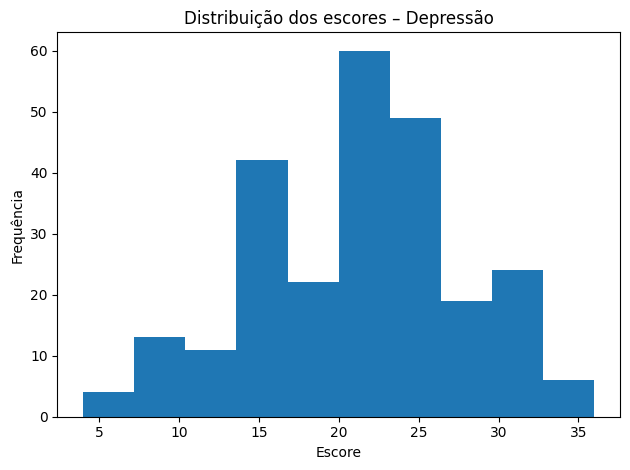

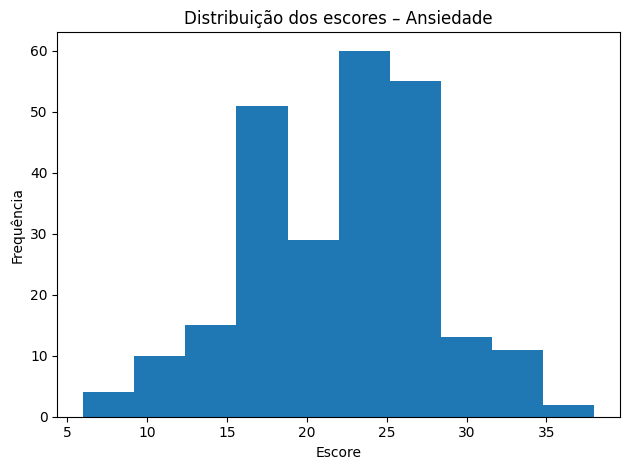

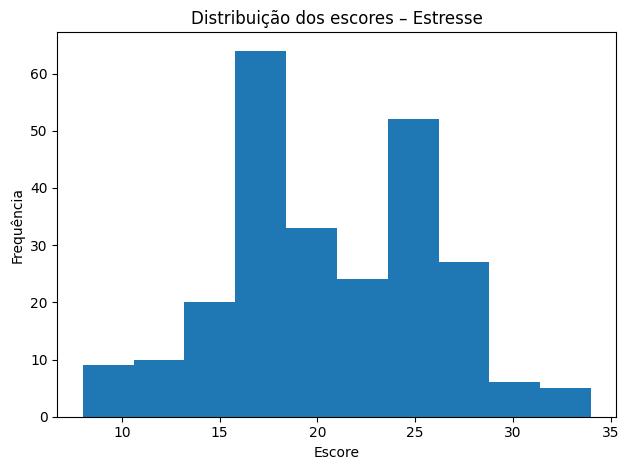

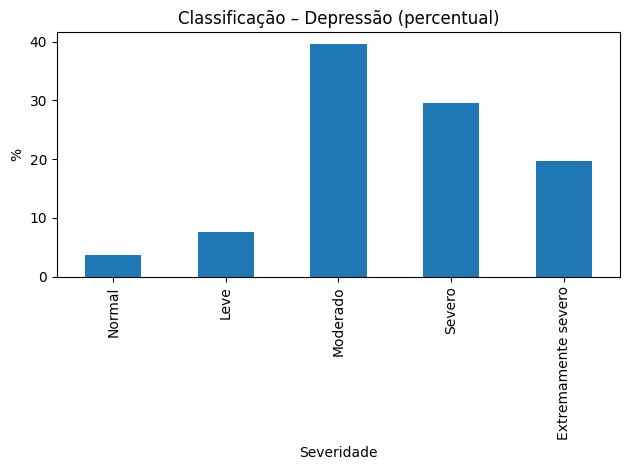

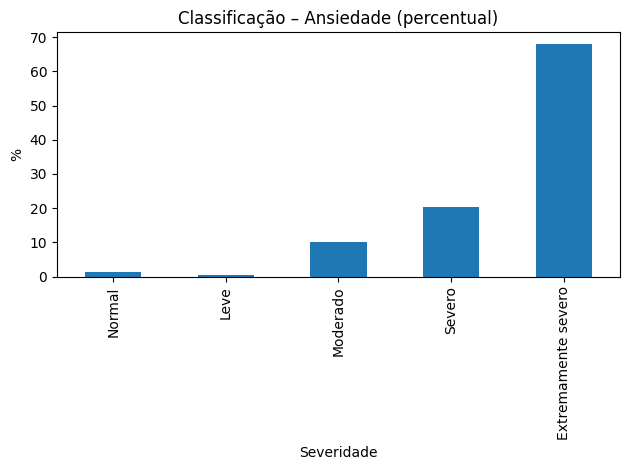

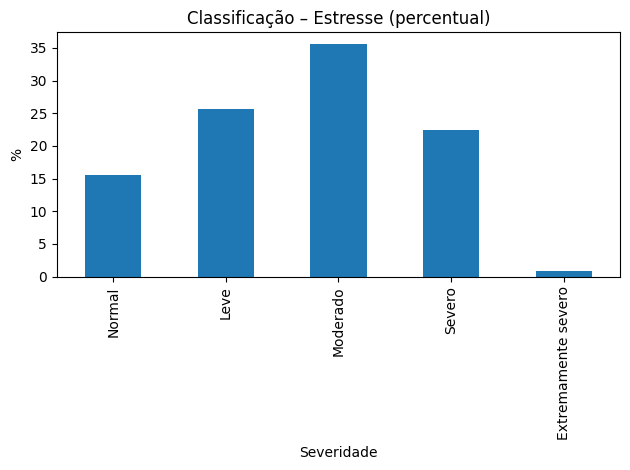

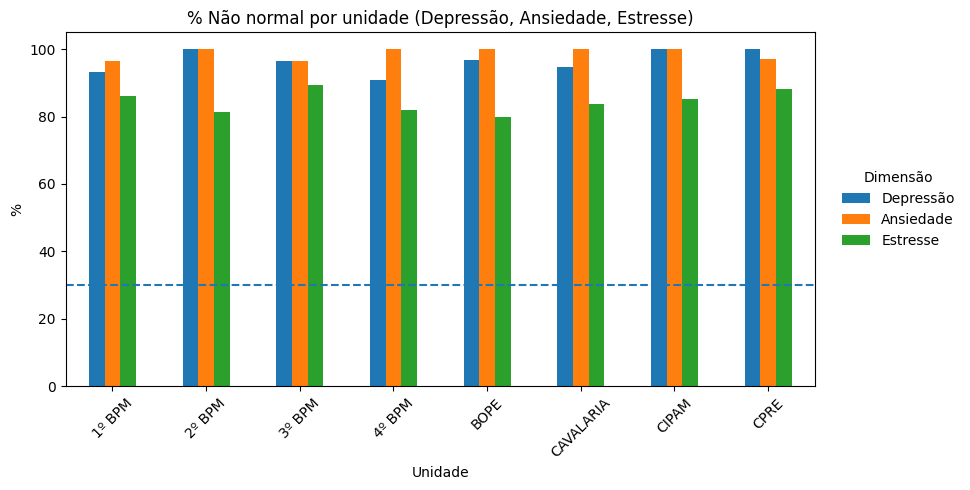

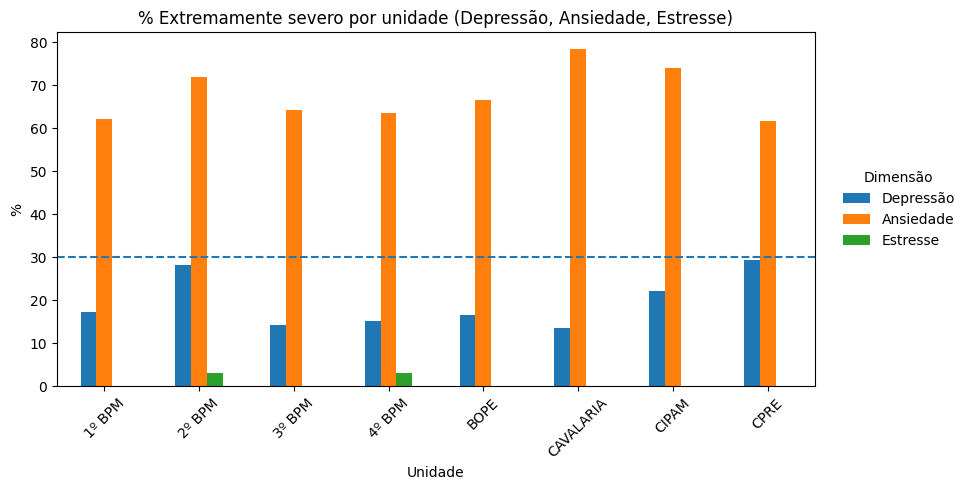

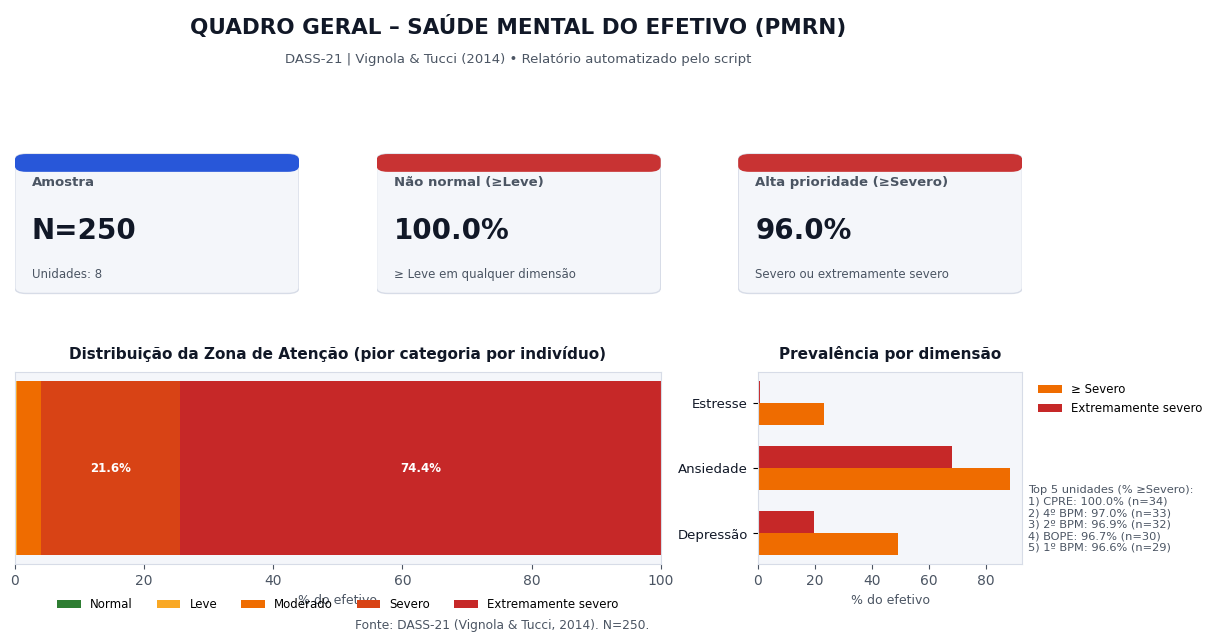

✅ Quadro geral salvo em: graficos\quadro_geral_pmrn_dashboard_fundo_claro_v2.png


In [84]:
import os
import matplotlib.pyplot as plt

PASTA_GRAFICOS = "graficos"
os.makedirs(PASTA_GRAFICOS, exist_ok=True)

ORDEM_SEVERIDADE = ['Normal', 'Leve', 'Moderado', 'Severo', 'Extremamente severo']

# Se você já definiu em outro lugar, pode remover esta linha:
LIMIAR_UNIDADE_ALERTA = 30.0  # linha de corte para destacar unidades (ajuste se quiser)

# -------------------------
# 1) Histogramas dos escores
# -------------------------
for col, titulo in [
    ('Depressao', 'Depressão'),
    ('Ansiedade', 'Ansiedade'),
    ('Estresse', 'Estresse')
]:
    fig, ax = plt.subplots()
    ax.hist(df[col], bins=10)
    ax.set_title(f"Distribuição dos escores – {titulo}")
    ax.set_xlabel("Escore")
    ax.set_ylabel("Frequência")

    fig.tight_layout()
    fig.savefig(f"{PASTA_GRAFICOS}/histograma_{col.lower()}.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# -------------------------
# 2) Classificações (barras) — ordem + percentual
# -------------------------
for col, titulo in [
    ('Class_Depressao', 'Depressão'),
    ('Class_Ansiedade', 'Ansiedade'),
    ('Class_Estresse', 'Estresse')
]:
    perc = (df[col].value_counts(normalize=True) * 100).reindex(ORDEM_SEVERIDADE, fill_value=0)

    fig, ax = plt.subplots()
    perc.plot(kind='bar', ax=ax)
    ax.set_title(f"Classificação – {titulo} (percentual)")
    ax.set_xlabel("Severidade")
    ax.set_ylabel("%")

    fig.tight_layout()
    fig.savefig(f"{PASTA_GRAFICOS}/classificacao_{col.lower()}_percentual.png", dpi=300, bbox_inches="tight")
    plt.show()
    plt.close(fig)

# -----------------------------------
# 3) Por unidade — % NÃO NORMAL e % EXTREMAMENTE SEVERO (corrigido)
# -----------------------------------
# IMPORTANTE: nomes de colunas sem espaço no Python
for dim_col, prefix in [
    ('Class_Depressao', 'dep'),
    ('Class_Ansiedade', 'ans'),
    ('Class_Estresse',  'est'),
]:
    df[f'{prefix}_nao_normal'] = (df[dim_col].astype(str).str.strip() != 'Normal').astype(int)
    df[f'{prefix}_extremamente_severo'] = (df[dim_col].astype(str).str.strip() == 'Extremamente severo').astype(int)

por_unidade_risco = df.groupby('unidade').agg(
    dep_nao_normal=('dep_nao_normal', 'mean'),
    dep_extremamente_severo=('dep_extremamente_severo', 'mean'),
    ans_nao_normal=('ans_nao_normal', 'mean'),
    ans_extremamente_severo=('ans_extremamente_severo', 'mean'),
    est_nao_normal=('est_nao_normal', 'mean'),
    est_extremamente_severo=('est_extremamente_severo', 'mean'),
).reset_index()

for c in por_unidade_risco.columns:
    if c != 'unidade':
        por_unidade_risco[c] = por_unidade_risco[c] * 100

# -----------------------------
# Gráfico 3.1: % NÃO NORMAL por unidade (3 dimensões)
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

dados_nao_normal = por_unidade_risco.set_index('unidade')[
    ['dep_nao_normal', 'ans_nao_normal', 'est_nao_normal']
].rename(columns={
    'dep_nao_normal': 'Depressão',
    'ans_nao_normal': 'Ansiedade',
    'est_nao_normal': 'Estresse'
})

dados_nao_normal.plot(kind='bar', ax=ax)

ax.set_title("% Não normal por unidade (Depressão, Ansiedade, Estresse)")
ax.set_ylabel("%")
ax.set_xlabel("Unidade")
ax.tick_params(axis='x', rotation=45)
ax.axhline(LIMIAR_UNIDADE_ALERTA, linestyle='--')

# legenda à direita (fora do gráfico)
ax.legend(title="Dimensão", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# deixa espaço à direita para a legenda não cortar
fig.tight_layout()
fig.subplots_adjust(right=0.82)

fig.savefig(f"{PASTA_GRAFICOS}/por_unidade_percentual_nao_normal.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)

# -----------------------------
# Gráfico 3.2: % EXTREMAMENTE SEVERO por unidade (3 dimensões)
# -----------------------------
fig, ax = plt.subplots(figsize=(10, 5))

dados_extremo = por_unidade_risco.set_index('unidade')[
    ['dep_extremamente_severo', 'ans_extremamente_severo', 'est_extremamente_severo']
].rename(columns={
    'dep_extremamente_severo': 'Depressão',
    'ans_extremamente_severo': 'Ansiedade',
    'est_extremamente_severo': 'Estresse'
})

dados_extremo.plot(kind='bar', ax=ax)

ax.set_title("% Extremamente severo por unidade (Depressão, Ansiedade, Estresse)")
ax.set_ylabel("%")
ax.set_xlabel("Unidade")
ax.tick_params(axis='x', rotation=45)
ax.axhline(LIMIAR_UNIDADE_ALERTA, linestyle='--')

# legenda à direita (fora do gráfico)
ax.legend(title="Dimensão", loc='center left', bbox_to_anchor=(1.02, 0.5), frameon=False)

# espaço para legenda
fig.tight_layout()
fig.subplots_adjust(right=0.82)

fig.savefig(f"{PASTA_GRAFICOS}/por_unidade_percentual_extremamente_severo.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)


# -----------------------------------
# 4) INFOGRÁFICO – QUADRO GERAL DA PMRN
# -----------------------------------

import os
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.patches import FancyBboxPatch, Patch

PASTA_GRAFICOS = "graficos"
os.makedirs(PASTA_GRAFICOS, exist_ok=True)

# -------------------------
# PADRÕES
# -------------------------
ORDEM_SEVERIDADE = ['Normal', 'Leve', 'Moderado', 'Severo', 'Extremamente severo']
ACIMA_MODERADO = {'Severo', 'Extremamente severo'}

# -------------------------
# MÉTRICAS (usa df já calculado no script)
# -------------------------
N_TOTAL = df.shape[0]
N_UNIDADES = df['unidade'].nunique()

pct_nao_normal = (
    (df['Class_Depressao'] != 'Normal') |
    (df['Class_Ansiedade'] != 'Normal') |
    (df['Class_Estresse']  != 'Normal')
).mean() * 100

pct_ge_severo = (
    df['Class_Depressao'].isin(ACIMA_MODERADO) |
    df['Class_Ansiedade'].isin(ACIMA_MODERADO) |
    df['Class_Estresse'].isin(ACIMA_MODERADO)
).mean() * 100

dist_zona = (df['Zona_Atencao'].value_counts(normalize=True) * 100).reindex(ORDEM_SEVERIDADE, fill_value=0)

dimensoes = ['Depressão', 'Ansiedade', 'Estresse']
ge_severo_dim = [
    df['Class_Depressao'].isin(ACIMA_MODERADO).mean() * 100,
    df['Class_Ansiedade'].isin(ACIMA_MODERADO).mean() * 100,
    df['Class_Estresse'].isin(ACIMA_MODERADO).mean() * 100,
]
extremo_dim = [
    (df['Class_Depressao'] == 'Extremamente severo').mean() * 100,
    (df['Class_Ansiedade'] == 'Extremamente severo').mean() * 100,
    (df['Class_Estresse'] == 'Extremamente severo').mean() * 100,
]

# Top 5 unidades por % >=Severo (qualquer dimensão)
df['_ge_severo_ind'] = (
    df['Class_Depressao'].isin(ACIMA_MODERADO) |
    df['Class_Ansiedade'].isin(ACIMA_MODERADO) |
    df['Class_Estresse'].isin(ACIMA_MODERADO)
)
top5 = (df.groupby('unidade')
          .agg(n=('codigo', 'count'),
               pct_ge_severo=('_ge_severo_ind', lambda x: x.mean() * 100))
          .sort_values('pct_ge_severo', ascending=False)
          .head(5))

# -------------------------
# PALETA FUNDO CLARO
# -------------------------
COLORS = {
    'bg': '#FFFFFF',
    'card': '#F4F6FA',
    'border': '#D7DCE7',
    'text': '#111827',
    'muted': '#4B5563',
    'green': '#2E7D32',
    'yellow': '#F9A825',
    'orange': '#EF6C00',
    'orange2': '#D84315',
    'red': '#C62828',
    'blue': '#1D4ED8',
}

sev_colors = {
    'Normal': COLORS['green'],
    'Leve': COLORS['yellow'],
    'Moderado': COLORS['orange'],
    'Severo': COLORS['orange2'],
    'Extremamente severo': COLORS['red'],
}

def accent_for_pct(pct):
    if pct < 20: return COLORS['green']
    if pct < 40: return COLORS['yellow']
    if pct < 60: return COLORS['orange']
    return COLORS['red']

def add_card(ax, title, value, subtitle, accent):
    ax.set_facecolor(COLORS['bg'])
    ax.axis('off')
    card = FancyBboxPatch(
        (0.02, 0.05), 0.96, 0.9,
        boxstyle="round,pad=0.02,rounding_size=0.04",
        linewidth=1.0, edgecolor=COLORS['border'], facecolor=COLORS['card']
    )
    ax.add_patch(card)
    acc = FancyBboxPatch(
        (0.02, 0.87), 0.96, 0.08,
        boxstyle="round,pad=0.02,rounding_size=0.04",
        linewidth=0, facecolor=accent, alpha=0.95
    )
    ax.add_patch(acc)
    ax.text(0.06, 0.82, title, color=COLORS['muted'], fontsize=9.5, weight='bold', va='top')
    ax.text(0.06, 0.55, value, color=COLORS['text'], fontsize=20, weight='bold', va='top')
    ax.text(0.06, 0.20, subtitle, color=COLORS['muted'], fontsize=8.5, va='top')

# -------------------------
# FIGURA (mais espaço horizontal p/ painel direito)
# -------------------------
fig = plt.figure(figsize=(13, 7.2), facecolor=COLORS['bg'])

# ↑ aumentei o wspace para empurrar o painel direito “mais para a direita”
gs = GridSpec(3, 6, figure=fig, height_ratios=[0.75, 1.7, 2.2], hspace=0.55, wspace=0.75)

# Título
ax_title = fig.add_subplot(gs[0, :])
ax_title.axis('off')
ax_title.text(
    0.5, 0.75, "QUADRO GERAL – SAÚDE MENTAL DO EFETIVO (PMRN)",
    ha='center', va='center', fontsize=15.5, color=COLORS['text'], weight='bold'
)
ax_title.text(
    0.5, 0.25, "DASS-21 | Vignola & Tucci (2014) • Relatório automatizado pelo script",
    ha='center', va='center', fontsize=9.5, color=COLORS['muted']
)

# Cards
ax1 = fig.add_subplot(gs[1, 0:2])
add_card(ax1, "Amostra", f"N={N_TOTAL}", f"Unidades: {N_UNIDADES}", accent=COLORS['blue'])

ax2 = fig.add_subplot(gs[1, 2:4])
add_card(ax2, "Não normal (≥Leve)", f"{pct_nao_normal:.1f}%", "≥ Leve em qualquer dimensão", accent=accent_for_pct(pct_nao_normal))

ax3 = fig.add_subplot(gs[1, 4:6])
add_card(ax3, "Alta prioridade (≥Severo)", f"{pct_ge_severo:.1f}%", "Severo ou extremamente severo", accent=accent_for_pct(pct_ge_severo))

# Barra empilhada – Zona de Atenção (com legenda separada)
ax_stack = fig.add_subplot(gs[2, 0:4])
ax_stack.set_facecolor(COLORS['card'])
for spine in ax_stack.spines.values():
    spine.set_color(COLORS['border'])

left = 0.0
y = 0
for cat in ORDEM_SEVERIDADE:
    w = float(dist_zona[cat])
    ax_stack.barh(y, w, left=left, height=0.45, color=sev_colors[cat])
    if w >= 6:
        ax_stack.text(left + w/2, y, f"{w:.1f}%", ha='center', va='center', fontsize=8.5, color=COLORS['bg'], weight='bold')
    left += w

ax_stack.set_xlim(0, 100)
ax_stack.set_yticks([])
ax_stack.set_xlabel("% do efetivo", color=COLORS['muted'], fontsize=9)
ax_stack.tick_params(axis='x', colors=COLORS['muted'])
ax_stack.set_title("Distribuição da Zona de Atenção (pior categoria por indivíduo)", color=COLORS['text'], pad=10, fontsize=11, weight='bold')

handles_sev = [Patch(facecolor=sev_colors[c], label=c) for c in ORDEM_SEVERIDADE]
ax_stack.legend(handles=handles_sev, loc='lower center', bbox_to_anchor=(0.50, -0.30), ncol=5, frameon=False, fontsize=8.5)

# -------------------------
# Painel DIREITO – Prevalência por dimensão (mais à direita + legenda mais à direita)
# -------------------------
ax_side = fig.add_subplot(gs[2, 4:6])
ax_side.set_facecolor(COLORS['card'])
for spine in ax_side.spines.values():
    spine.set_color(COLORS['border'])

# empurra o conteúdo interno um pouco para a direita (mais margem esquerda)
pos = ax_side.get_position()
ax_side.set_position([pos.x0 + 0.015, pos.y0, pos.width - 0.015, pos.height])

ypos = list(range(len(dimensoes)))
bar_h = 0.34

ax_side.barh([y - bar_h/2 for y in ypos], ge_severo_dim, height=bar_h, color=COLORS['orange'], label="≥ Severo")
ax_side.barh([y + bar_h/2 for y in ypos], extremo_dim, height=bar_h, color=COLORS['red'], label="Extremamente severo")

ax_side.set_yticks(ypos)
ax_side.set_yticklabels(dimensoes, fontsize=9.5, color=COLORS['text'])
ax_side.set_xlabel("% do efetivo", color=COLORS['muted'], fontsize=9)
ax_side.tick_params(axis='x', colors=COLORS['muted'])
ax_side.set_title("Prevalência por dimensão", color=COLORS['text'], pad=10, fontsize=11, weight='bold')

# legenda mais para a direita (evita sobrepor qualquer coisa)
ax_side.legend(loc='upper left', bbox_to_anchor=(1.02, 1.00), frameon=False, fontsize=8.5)

# Top 5 (fonte menor e mais afastado, sem sobreposição)
txt = "Top 5 unidades (% ≥Severo):\n"
for i, (u, row) in enumerate(top5.iterrows(), start=1):
    txt += f"{i}) {u}: {row['pct_ge_severo']:.1f}% (n={int(row['n'])})\n"

ax_side.text(1.02, 0.00, txt, transform=ax_side.transAxes, fontsize=8.2, color=COLORS['muted'], va='bottom')

# Rodapé
fig.text(0.5, 0.02, f"Fonte: DASS-21 (Vignola & Tucci, 2014). N={N_TOTAL}.",
         ha='center', color=COLORS['muted'], fontsize=8.8)

out_path = os.path.join(PASTA_GRAFICOS, "quadro_geral_pmrn_dashboard_fundo_claro_v2.png")
fig.savefig(out_path, dpi=300, bbox_inches="tight", facecolor=COLORS['bg'])
plt.show()
plt.close(fig)

print("✅ Quadro geral salvo em:", out_path)



In [82]:
# ==========================================================
# 10. SALVAR EXCEL (com abas)
# ==========================================================
arquivo = "resultado_final_dass21.xlsx"

with pd.ExcelWriter(arquivo, engine='openpyxl') as writer:
    individual.to_excel(writer, sheet_name="Individual", index=False)
    matriz_individual.to_excel(writer, sheet_name="Matriz_Individual", index=False)
    por_unidade.to_excel(writer, sheet_name="Por_Unidade", index=False)
   


In [83]:
# ==========================================================
# 11. CORES (Excel)
# ==========================================================
cores = {
    'Normal': PatternFill('solid', 'C6EFCE'),
    'Leve': PatternFill('solid', 'FFEB9C'),
    'Moderado': PatternFill('solid', 'F4B084'),
    'Severo': PatternFill('solid', 'ED7D31'),
    'Extremamente severo': PatternFill('solid', 'FF0000'),
    'Normal (>50%)': PatternFill('solid', 'C6EFCE'),
    'Alerta (≤50%)': PatternFill('solid', 'FFEB9C'),
    'AVISO_INDIVIDUO': PatternFill('solid', 'FFC7CE'),  # vermelho claro
    'AVISO_UNIDADE': PatternFill('solid', 'FFE699')    # amarelo forte
}

wb = load_workbook(arquivo)

# ==========================================================
# COLORIR AVISO DO INDIVÍDUO
# ==========================================================
ws = wb['Individual']
headers = [cell.value for cell in ws[1]]

if 'Aviso_Individuo' in headers:
    col_aviso = headers.index('Aviso_Individuo') + 1

    for r in range(2, ws.max_row + 1):
        if ws.cell(r, col_aviso).value:
            ws.cell(r, col_aviso).fill = cores['AVISO_INDIVIDUO']


# ==========================================================
# COLORIR ABA "Matriz_Individual"
# ==========================================================

ws = wb['Matriz_Individual']
headers = [cell.value for cell in ws[1]]

def achar_coluna(*nomes):
    for nome in nomes:
        if nome in headers:
            return headers.index(nome) + 1
    raise ValueError(f"Coluna não encontrada: {nomes}. Cabeçalhos: {headers}")

col_dep = achar_coluna('Depressão', 'Depressao')
col_ans = achar_coluna('Ansiedade')
col_est = achar_coluna('Estresse')

for r in range(2, ws.max_row + 1):
    for col in (col_dep, col_ans, col_est):
        valor = ws.cell(r, col).value
        if valor is None:
            continue

        valor = str(valor).strip()

        if valor.lower().startswith('extrem'):
            valor = 'Extremamente severo'

        fill = cores.get(valor)
        if fill:
            ws.cell(r, col).fill = fill


wb.save(arquivo)

print(f"\n🎉 Finalizado. Excel gerado: {arquivo}")



🎉 Finalizado. Excel gerado: resultado_final_dass21.xlsx
